# Dyer nighttime lights — discussion checkpoint

## 1. Data, methods, and decisions

- **Data:** QA-screened, non-gap-filled Black Marble VNP46A2 radiance; structural
  reallocation at native ~500 m and 10 m. Baseline: **February 5–April 1, 2025**;
  event forecasts: **April 2–17**. TING is not used here.
- **M0:** per-cell baseline median with robust variability pooled by brightness.
  **M1:** heavily regularized local-level forecast (process/observation variance
  ratio 0.001). Both require 10 baseline observations, use scale floor 0.1 and prior
  weight 20, and remain frozen during the event. No models are refitted here.
- **Support:** sections 2–3 use matched native A2/reallocation cell-nights, a
  stricter subset than the original A2-only run. Section 4 retains the 10 m run's
  own valid observations.
- **Interpretation:** negative residual means dimmer than predicted, not confirmed
  outage. Clouds remain missing. Changing coverage changes the pixels contributing
  to spatial medians. Model uncertainty remains uncalibrated.
- **Clusters:** four exploratory groups of April 7–14 residual trajectories;
  minimum four observed dates. Missing-aware k-means excludes missing entries and
  fits all eligible cells. Colors match within each section; group identities are
  not aligned across sections. Nonrandom missingness can still bias comparisons.
- **10 m:** correlated structural proxy pixels, not independent measurements;
  the allocation uses contemporary 2026 structural data for 2025 radiance.

Details: [native models](../docs/COUNTERFACTUAL_IMPLEMENTATION.md),
[reallocation](../docs/REALLOCATION_NATIVE_CHECK.md),
[10 m models](../docs/COUNTERFACTUAL_10M.md).

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, Markdown
import rasterio
from rasterio.transform import Affine

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "scripts/discussion_checkpoint.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# Refresh plotting helpers when rerunning this cell in an existing IDE kernel.
import importlib
import scripts.discussion_checkpoint as checkpoint_helpers
importlib.reload(checkpoint_helpers)
from scripts.discussion_checkpoint import (
    load_scenes, projected_box, reference_figure, observed_montage, comparison_panel,
    radiance_figure, residual_figure, cluster_scene, cluster_figures, close_comparison,
    file_hash, COLORS, image_normalizations,
)

# Main discussion controls. Geographic bounds only select the same area across grids.
ZOOM_WGS84 = (-89.48, 35.94, -89.18, 36.17)  # Dyersburg + Newbern, eastern Dyer
CLOSE_WGS84 = (-89.425, 36.005, -89.345, 36.080)  # Dyersburg close-up
ZOOM = projected_box(*ZOOM_WGS84)
CLOSE = projected_box(*CLOSE_WGS84)
IMAGE_DATES = pd.date_range("2025-04-02", "2025-04-14")
SERIES_DATES = pd.date_range("2025-04-02", "2025-04-14")
CLUSTER_DATES = pd.date_range("2025-04-07", "2025-04-14")
CLOSE_DATES = pd.to_datetime(["2025-04-08", "2025-04-09", "2025-04-11"])
N_CLUSTERS = 4
MIN_CLUSTER_DATES = 4
CLUSTER_MAX_ITER = 120
CLUSTER_SEED = 7
# None = full displayed-data range, shared across datasets and nights.
RADIANCE_VMAX = None
RESIDUAL_LIMIT = None
RESIDUAL_LINTHRESH = 0.5  # Linear band is +/- this radiance value.

OUTPUT = ROOT / "data/published/discussion_checkpoint"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"font.size": 10, "figure.dpi": 110, "savefig.dpi": 140})
print("Verifying and loading existing inputs; the 10 m arrays stay memory-mapped...")
scenes, input_hashes = load_scenes(ROOT)
for scene in scenes.values():
    print(scene.title, scene.observed.shape)


# Normalize colors only: arrays, model outputs, statistics, and clusters stay in original units.
RADIANCE_NORM, RESIDUAL_NORM = image_normalizations(
    scenes, ZOOM, IMAGE_DATES, close=CLOSE, close_dates=CLOSE_DATES,
    radiance_vmax=RADIANCE_VMAX, residual_limit=RESIDUAL_LIMIT,
    linthresh=RESIDUAL_LINTHRESH,
)
RADIANCE_VMAX = float(RADIANCE_NORM.vmax)
RESIDUAL_LIMIT = float(RESIDUAL_NORM.vmax)
print(f"Shared log1p radiance colors: 0 to {RADIANCE_VMAX:.3g}")
print(f"Shared symmetric-log residual colors: +/-{RESIDUAL_LIMIT:.3g}; linear within +/-{RESIDUAL_LINTHRESH}")


Verifying and loading existing inputs; the 10 m arrays stay memory-mapped...
VIIRS A2 · matched native support (72, 81, 139)
Reallocation · native ~500 m (72, 81, 139)
Reallocation · 10 m proxy (72, 4097, 5533)
Shared log1p radiance colors: 0 to 396
Shared symmetric-log residual colors: +/-206; linear within +/-0.5


### Reading the figures
Radiance images use **log1p color normalization**, preserving valid zeros.
Residual images use **zero-centered symmetric-log normalization** with blue for
negative values, white at zero, and red for positive values. The residual scale
is linear within ±0.5 nW cm⁻² sr⁻¹ and logarithmic outside that band; adjust
`RESIDUAL_LINTHRESH` in the controls to change it.

Limits are derived from the full-resolution displayed data and shared across
all datasets, methods, and dates—no percentile clipping or per-image rescaling.
Colorbar tick labels remain in original radiance units. Manual limit overrides
are available in the controls. **Only image colors change**: time-series axes,
statistics, residual values, and categorical cluster colors are unchanged.

Native plots use the cells' actual projected edges. Fine overview images are
sampled only for display. Missing-day gaps in the time series are not interpolated.
Reference images show **per-pixel baseline medians**. Reference lines show the
**median of baseline nightly spatial medians** for the stated area. M1 residuals
use M1's forecast, even when the reference image displays the baseline median.
Each diagnostic CSV also records the number of valid pixels contributing each night.

The notebook writes shareable PNGs, a multipage PDF, diagnostic tables, cluster
GeoTIFFs, and provenance under `data/published/discussion_checkpoint/`.
Use this project's `.venv` with `requirements-checkpoint.txt` installed.

In [2]:
# Export helpers. Run the notebook in order; the final cell closes the PDF.
report_pdf = PdfPages(OUTPUT / "discussion_checkpoint.pdf")
figure_paths = []
cluster_summaries = []
cluster_results = {}


def publish(fig, name):
    path = OUTPUT / f"{name}.png"
    fig.savefig(path, dpi=140, facecolor="white")
    report_pdf.savefig(fig, facecolor="white")
    figure_paths.append(path)
    display(fig)
    plt.close(fig)


def save_table(table, name):
    table.to_csv(OUTPUT / f"{name}.csv", index=False)


def save_cluster_map(scene, image, name, info):
    rr, cc, _, _ = scene.region(ZOOM)
    transform = scene.transform @ Affine.translation(cc.start, rr.start)
    path = OUTPUT / f"{name}.tif"
    with rasterio.open(path, "w", driver="COG", width=image.shape[1], height=image.shape[0],
                       count=1, dtype="uint8", crs=f"EPSG:{scene.crs}", transform=transform,
                       nodata=0, compress="DEFLATE", overview_resampling="NEAREST") as dst:
        dst.write(np.where(np.isfinite(image), image, 0).astype("uint8"), 1)
        dst.update_tags(description="Exploratory residual clusters; not outage labels",
                        palette=json.dumps({str(i+1): c for i, c in enumerate(COLORS[:info["clusters"]])}))


## 2A. VIIRS A2 — M0

### Baseline reference and built-up-area zoom

Left: the full Dyer analysis footprint. Right: the eastern zoom including Dyersburg
and Newbern, **the built-up areas of interest**.

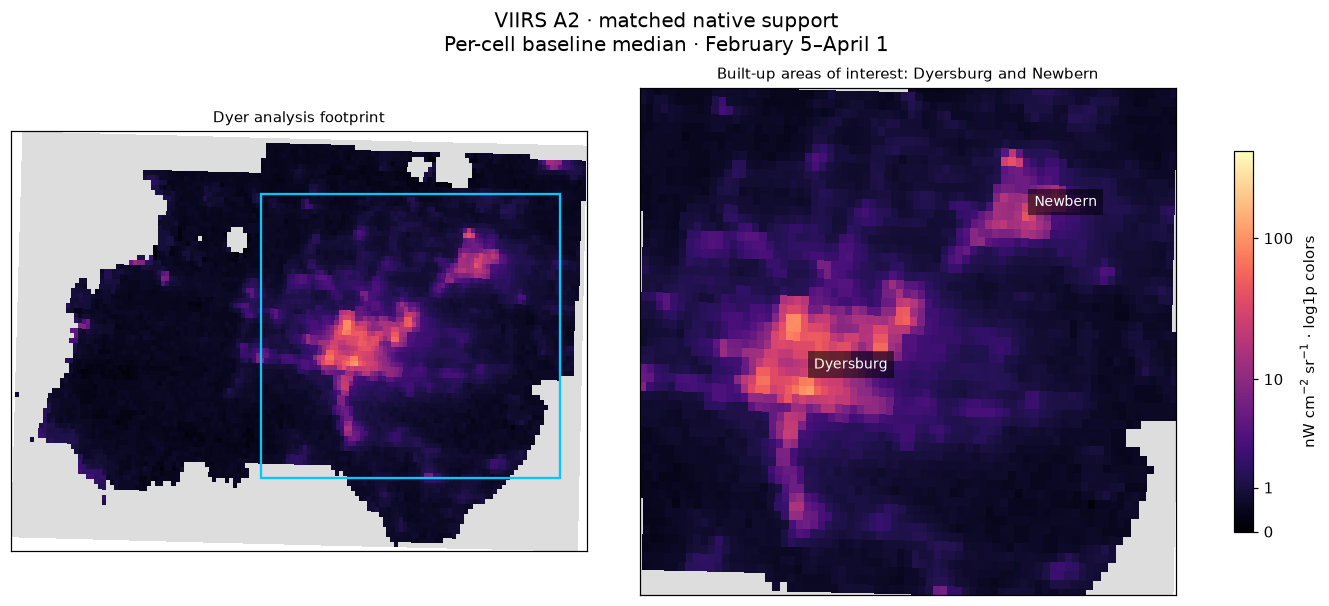

In [3]:
scene = scenes["a2"]
method = "M0"
prefix = "2a"
publish(reference_figure(scene, ZOOM, RADIANCE_VMAX, norm=RADIANCE_NORM), f"{prefix}_01_reference")

### Baseline / observed / residual comparison

One row per date. The left image is the same baseline median in every row; the
center is observed radiance and the right is observed minus the **M0 prediction**.
M0 uses the baseline median as its reference for supported cells.
Missing residuals also include insufficient baseline support.

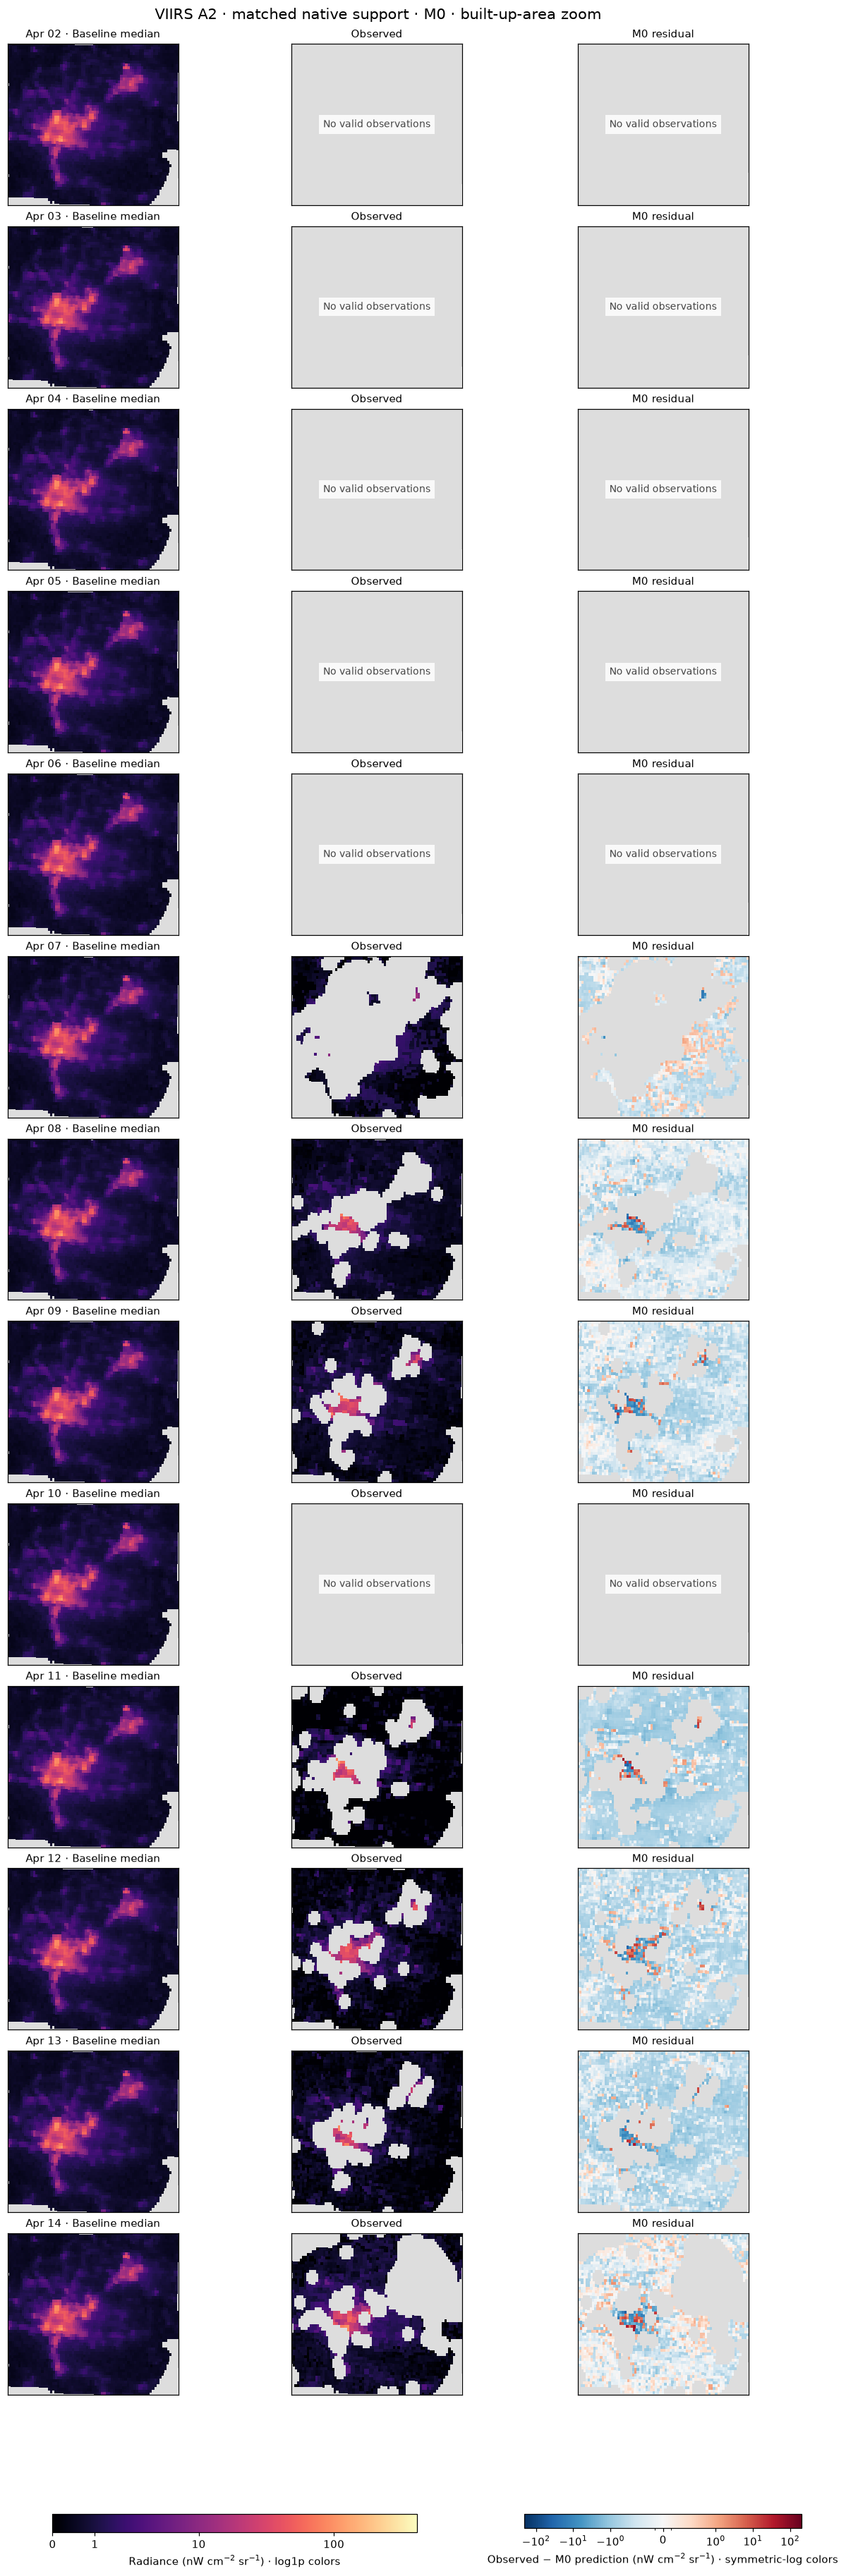

In [4]:
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_03_comparison")

### Spatial-median time series

The first plot summarizes the **full scene**, and the second summarizes only the
built-up-area zoom. Each reference line is the median of baseline nightly spatial
medians for that same area. Missing observations are excluded; an entirely missing
night has no plotted point. The contributing pixel set can vary by night.

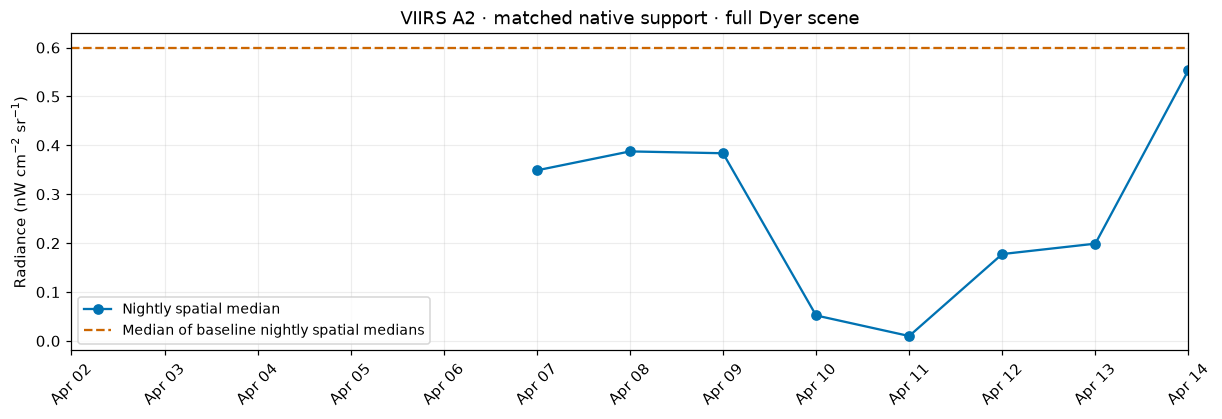

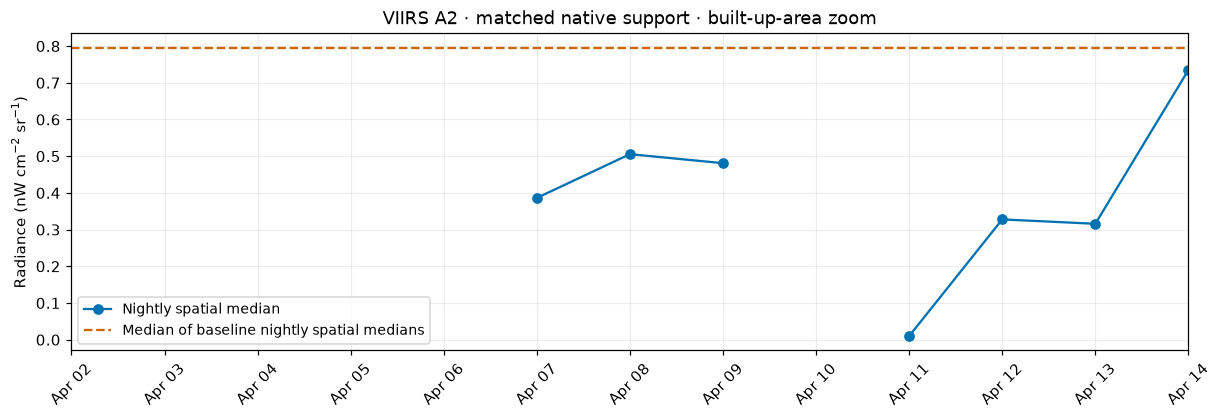

In [5]:
fig, table = radiance_figure(scene, SERIES_DATES)
publish(fig, f"{prefix}_04_full_scene_radiance")
save_table(table, f"{prefix}_full_scene_radiance")
fig, table = radiance_figure(scene, SERIES_DATES, ZOOM, "built-up-area zoom")
publish(fig, f"{prefix}_05_zoom_radiance")
save_table(table, f"{prefix}_zoom_radiance")

### Exploratory residual clusters

Cluster raw residual trajectories from April 7–14. Cells need at least four valid
residual dates; missing entries have zero weight in the distance and centroid
updates. Residual amplitude is retained (no per-cell standardization). The clustering
uses all eligible pixels, without requiring spatial adjacency. Cluster labels are
ordered from lower to higher mean centroid residual, **not by outage confidence**.

Group medians use the available observations within each group on each date, so
membership is fixed but the contributing subset may change. Colors match exactly
between the profile plot and spatial map. Inspect the convergence and coverage
summary below before interpreting groups.

Clustering VIIRS A2 · matched native support / M0 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,3105,4,23,True,4,7,2a,a2,M0


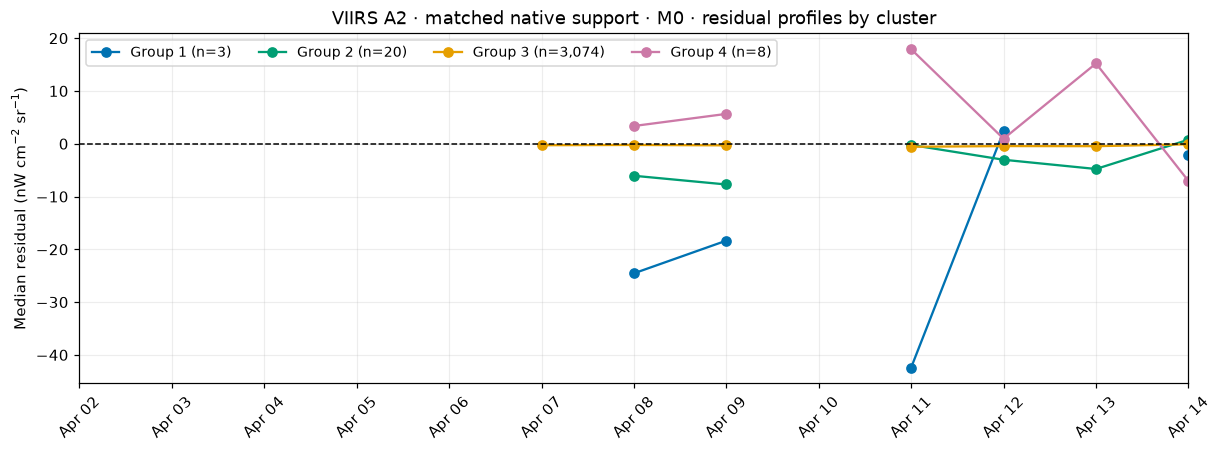

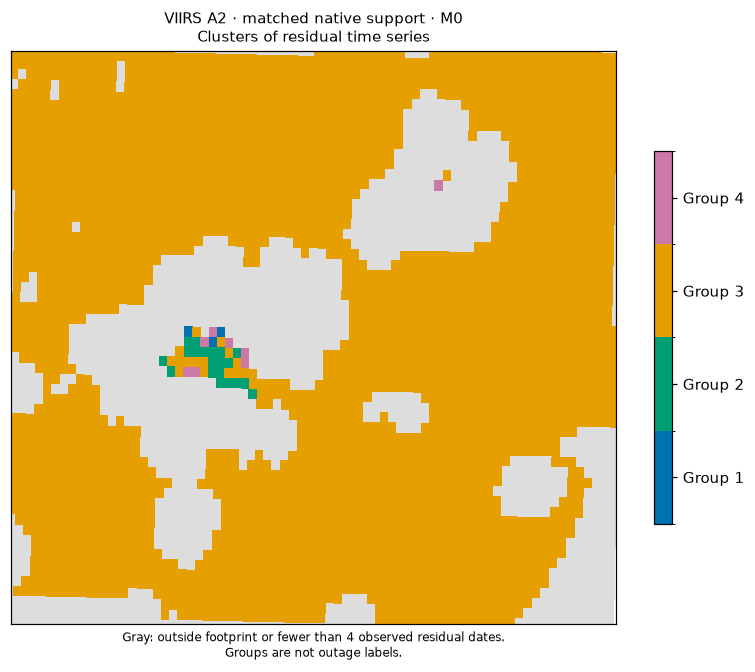

In [6]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table

## 2B. VIIRS A2 — M1 method...
### Baseline / observed / residual comparison

One row per date. The left image is the same baseline median in every row; the
center is observed radiance and the right is observed minus the **M1 prediction**.
For M1, the baseline median shown on the left is not its local-level prediction.
Missing residuals also include insufficient baseline support.

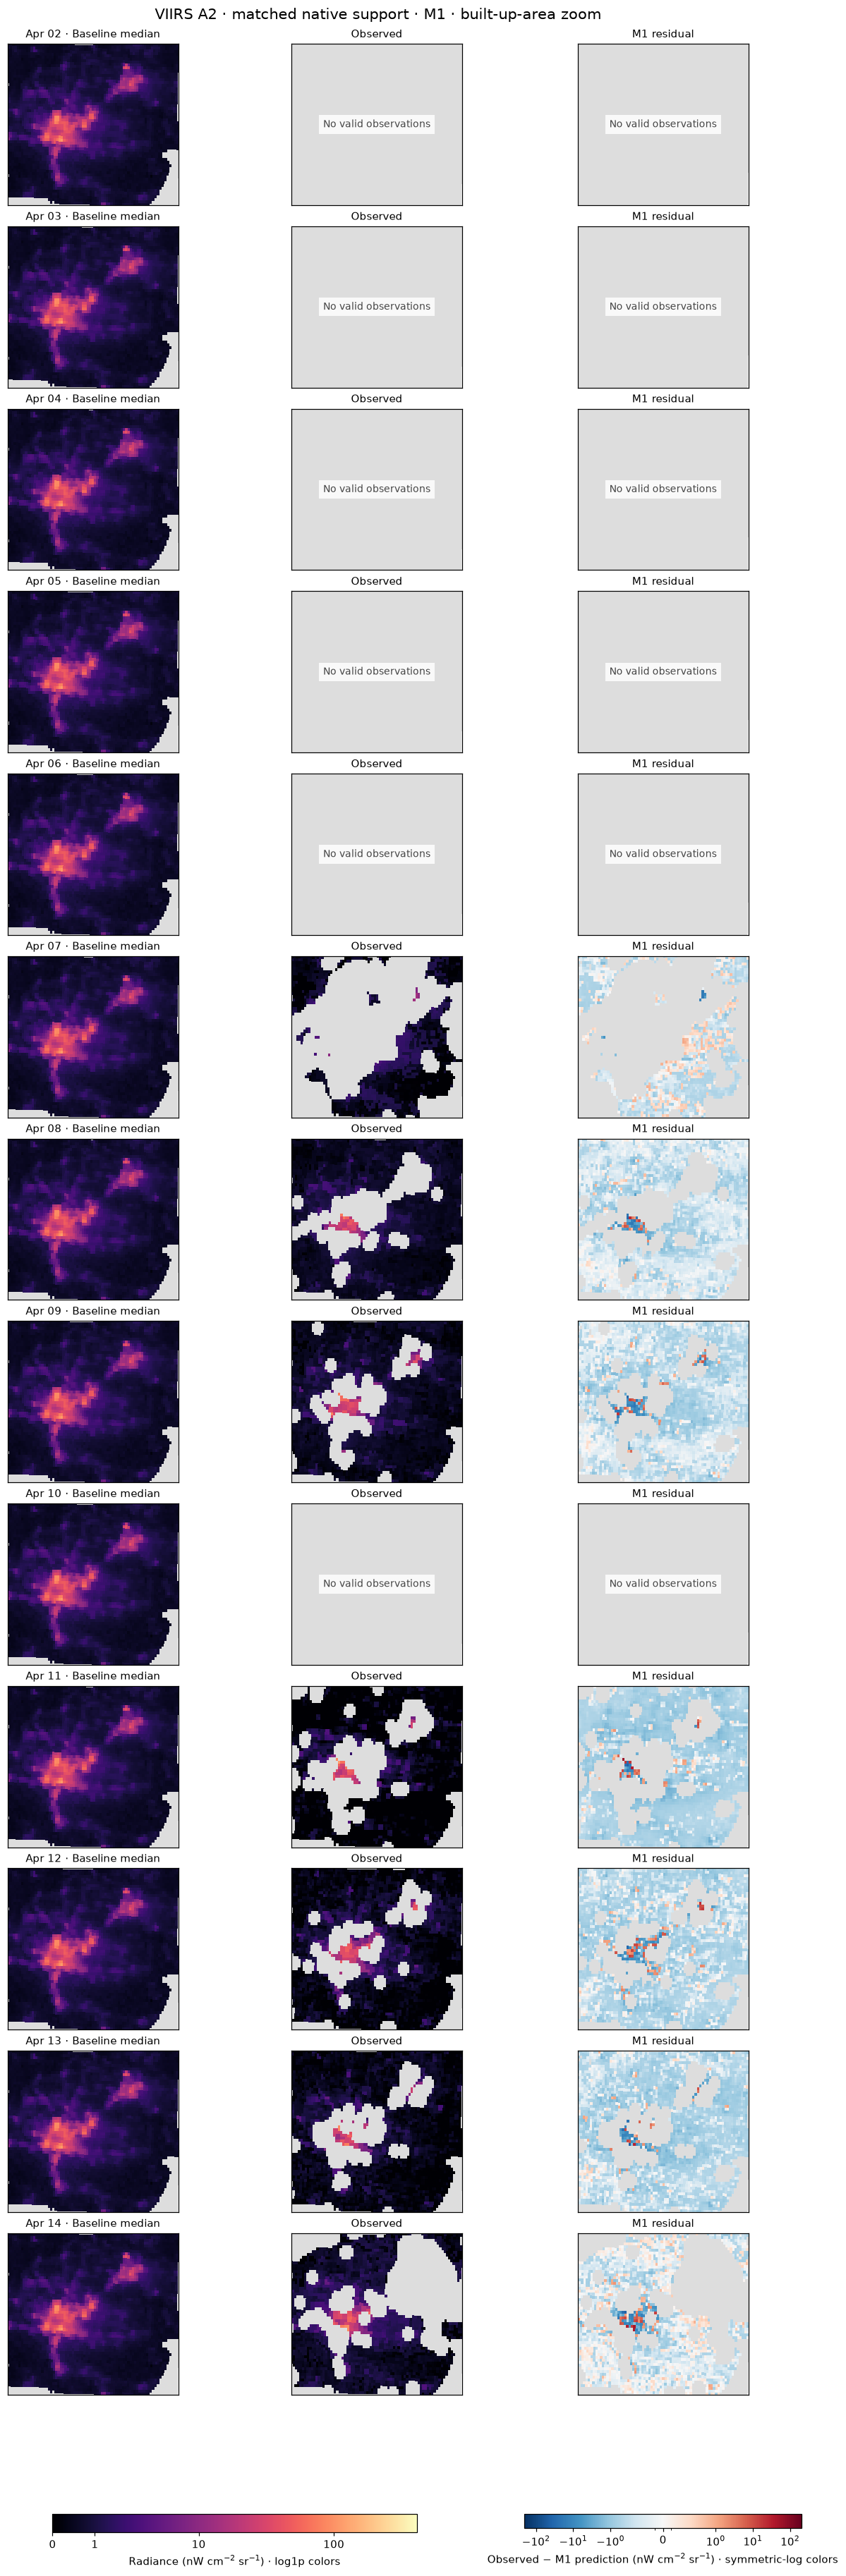

In [7]:
method = "M1"
prefix = "2b"
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_03_comparison")

### Exploratory residual clusters (same cluster method, but using M1 residuals).

Clustering VIIRS A2 · matched native support / M1 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,3105,4,30,True,4,7,2b,a2,M1


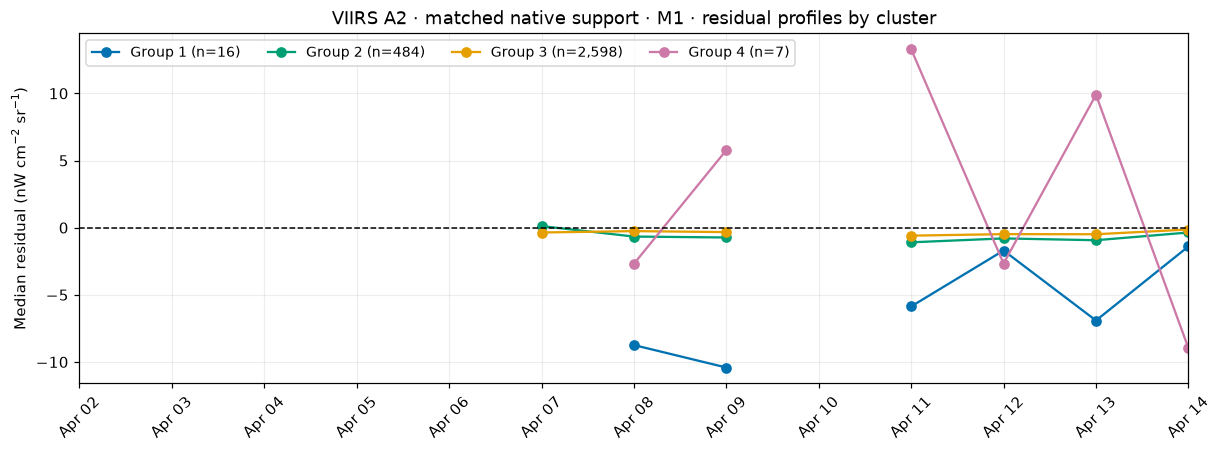

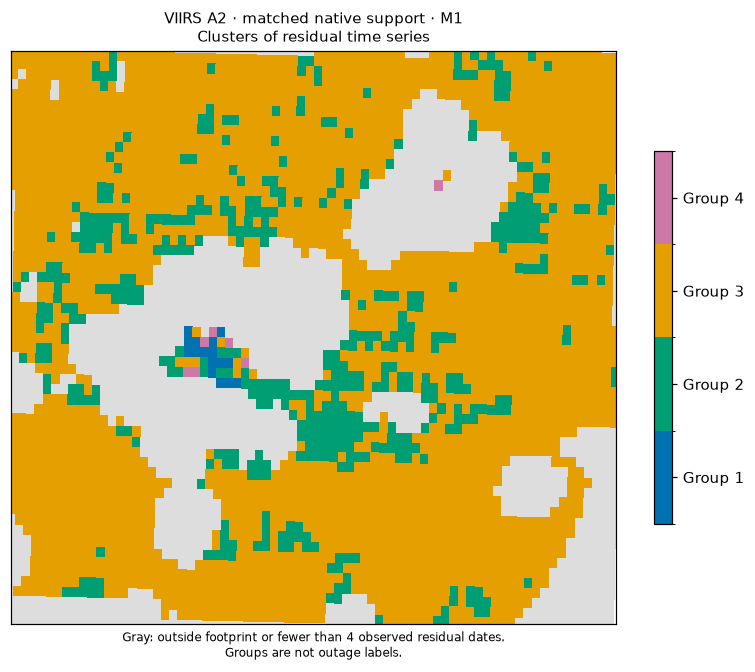

In [8]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table

## 3. Reallocation at native ~500 m — M0

This layer is producted by taking as input the Black Marble VNP46A2 radiance and convolving a kernel that redistributes the radiance as informed by building and roads as mapped by Overture to produce a nighttime lights reallocation proxy at 10m resolution. For this layer, it is aggregated to a 500m resolution that corresponds with the original input data.

Main takeaway here is that this is quite similar to the VIIRS A2 output as expected.

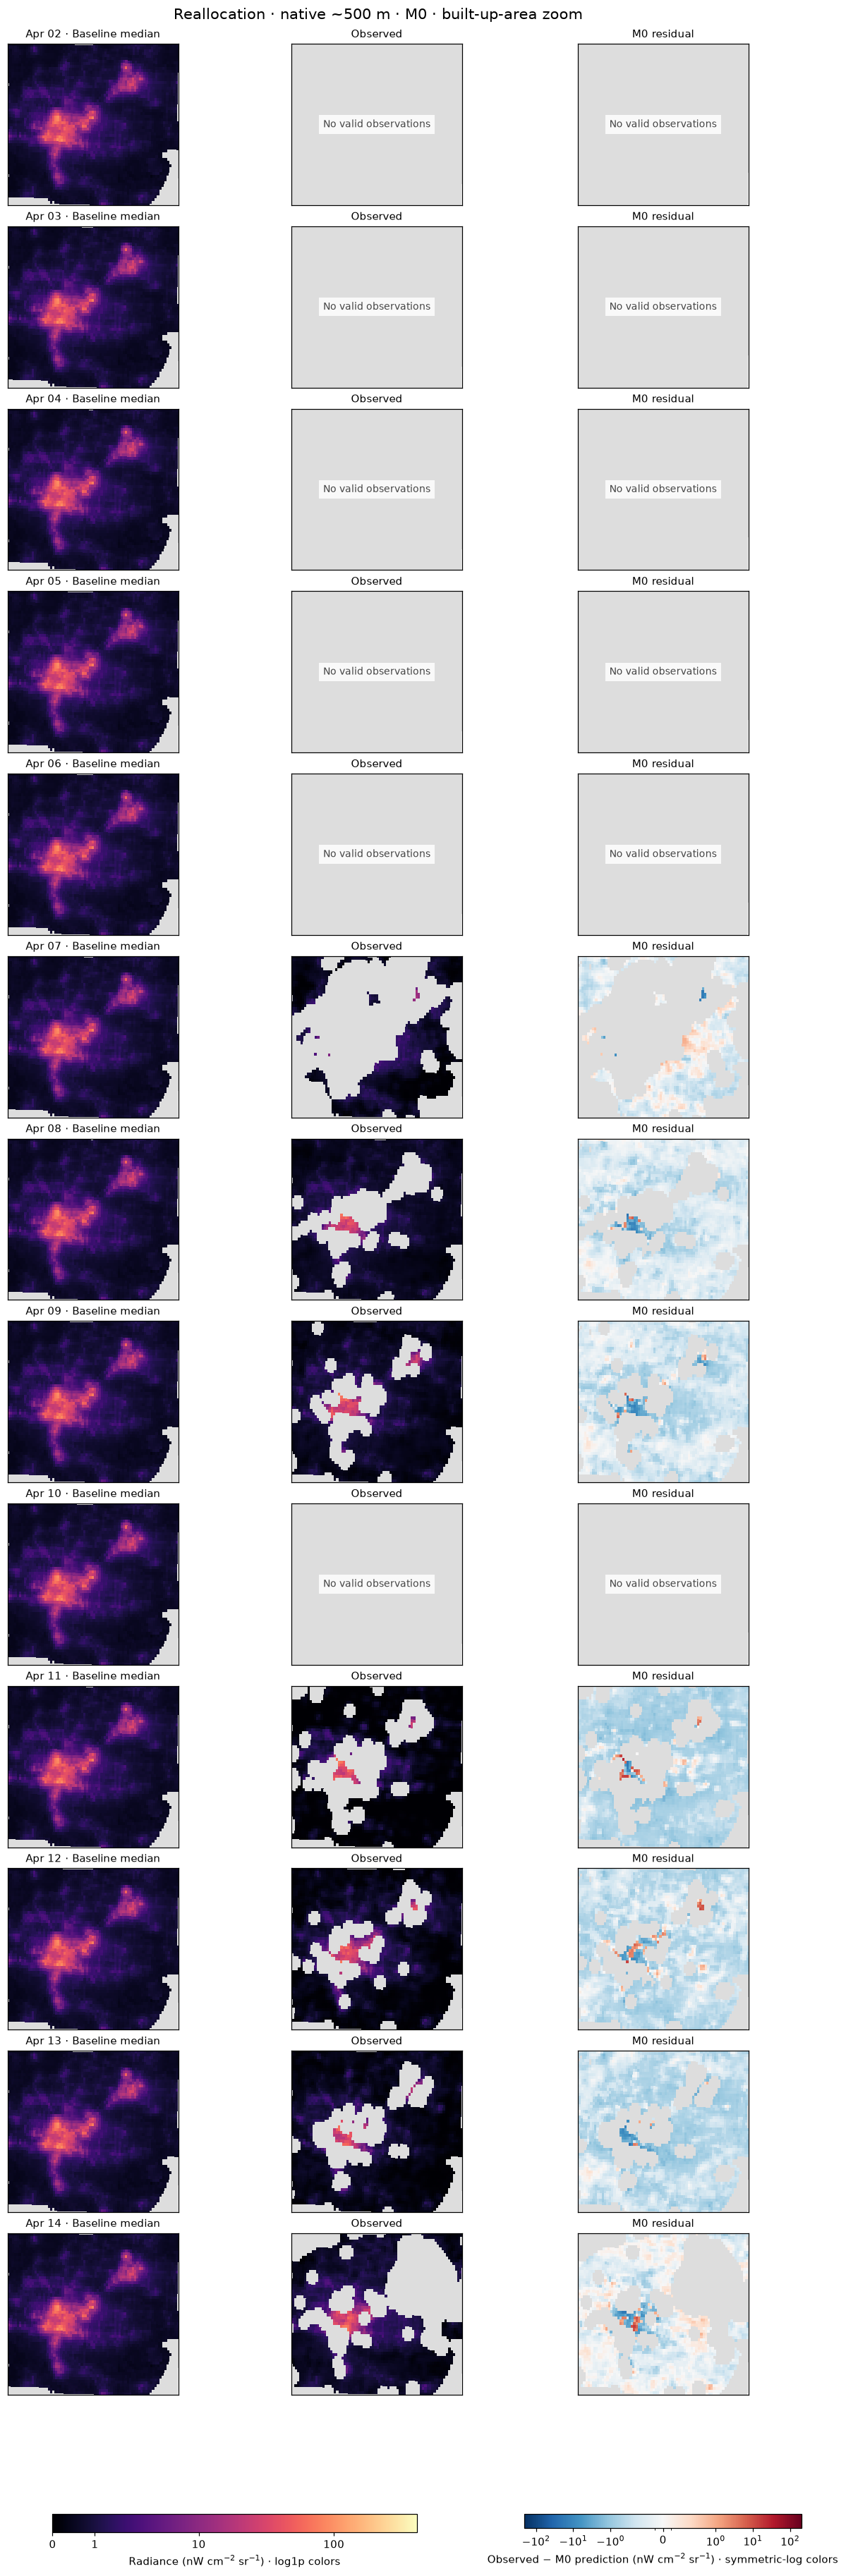

In [9]:
scene = scenes["allocated500"]
method = "M0"
prefix = "3a"
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_03_comparison")

### Spatial-median time series (rellocation at 500m for M0 method)

Same method as w/ the A2 data -- again the note here is that it shows near equivalent results.

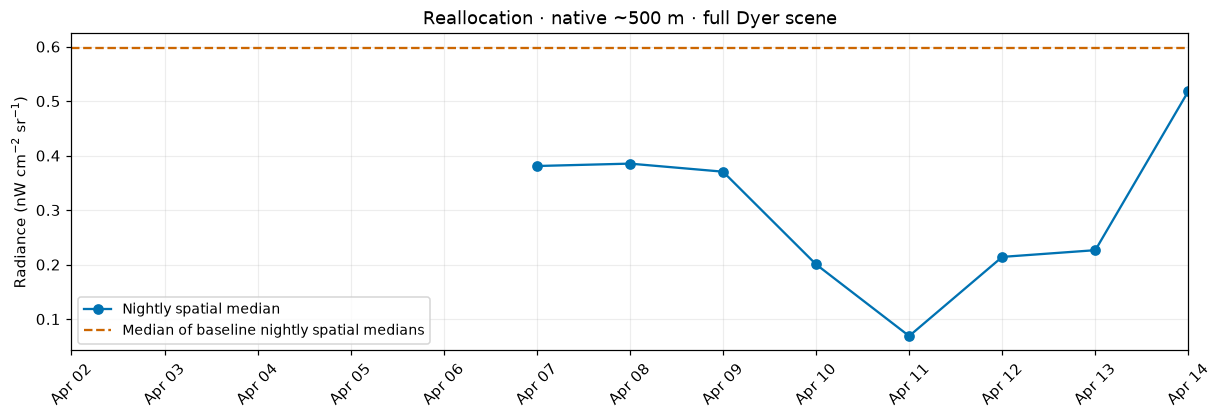

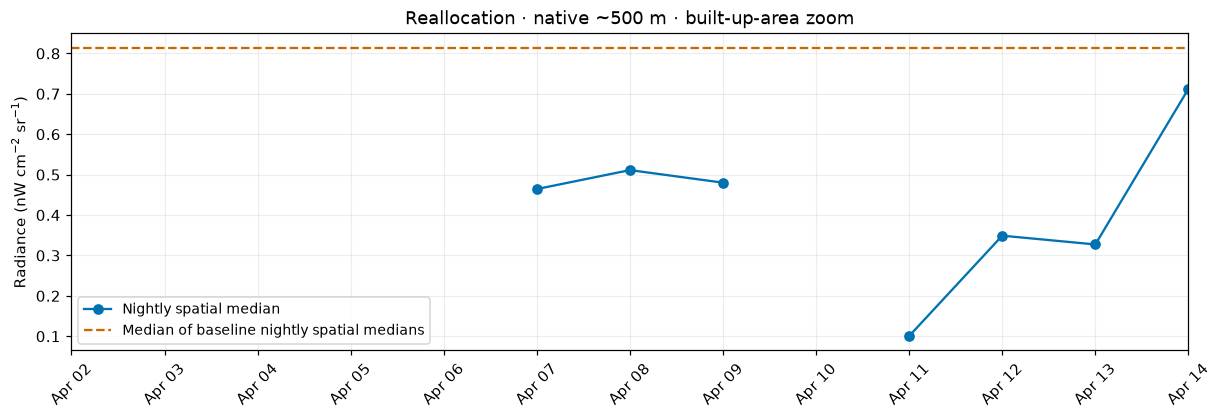

In [10]:
fig, table = radiance_figure(scene, SERIES_DATES)
publish(fig, f"{prefix}_04_full_scene_radiance")
save_table(table, f"{prefix}_full_scene_radiance")
fig, table = radiance_figure(scene, SERIES_DATES, ZOOM, "built-up-area zoom")
publish(fig, f"{prefix}_05_zoom_radiance")
save_table(table, f"{prefix}_zoom_radiance")

## Note: The reallocation results at 500m for the M1 method was also near equivalent to the VIIRS A2 approach, so we're omitting those plots and analysis here and jumping to the reallocation at 10m method.


## 4A. Reallocation at 10 m — M0

### Baseline reference and built-up-area zoom

Left: the full Dyer analysis footprint. Right: the eastern zoom including Dyersburg
and Newbern.

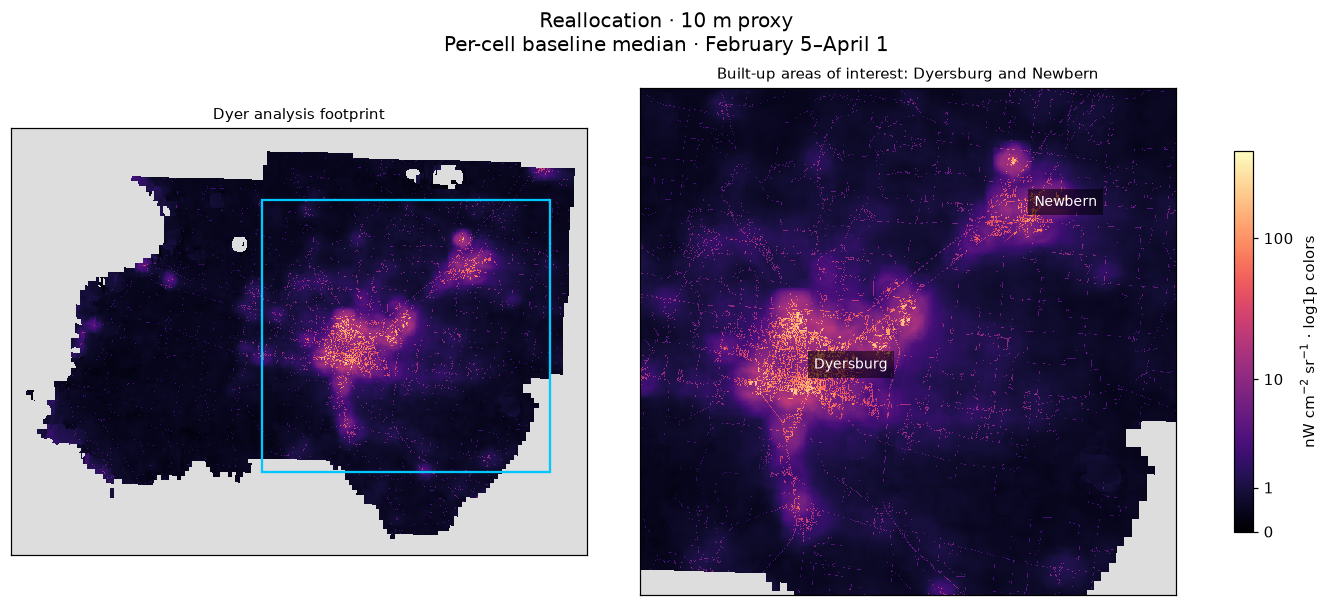

In [11]:
scene = scenes["allocated10"]
method = "M0"
prefix = "4a"
publish(reference_figure(scene, ZOOM, RADIANCE_VMAX, norm=RADIANCE_NORM), f"{prefix}_01_reference")

### Baseline / observed / residual comparison

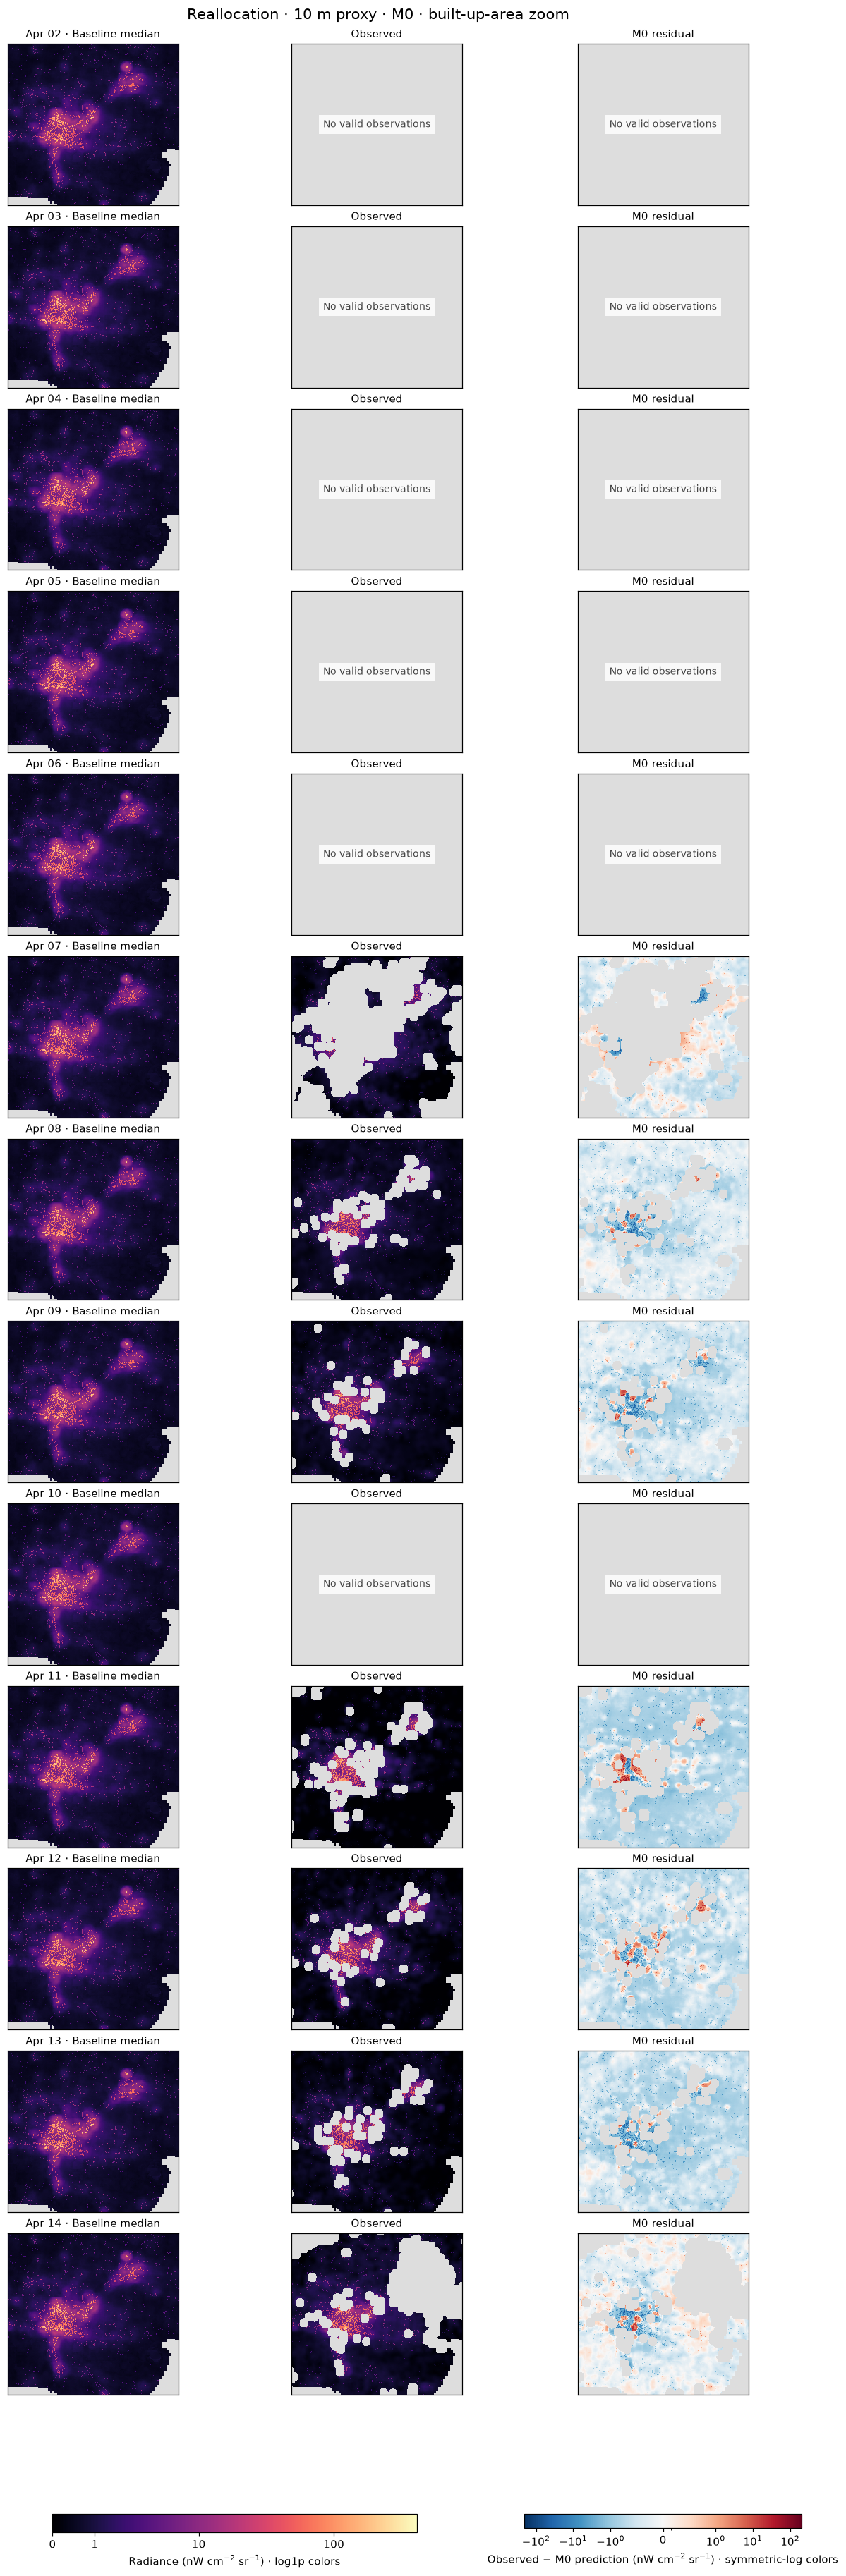

In [12]:
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_03_comparison")

### Spatial-median time series (rellocation at 10m)

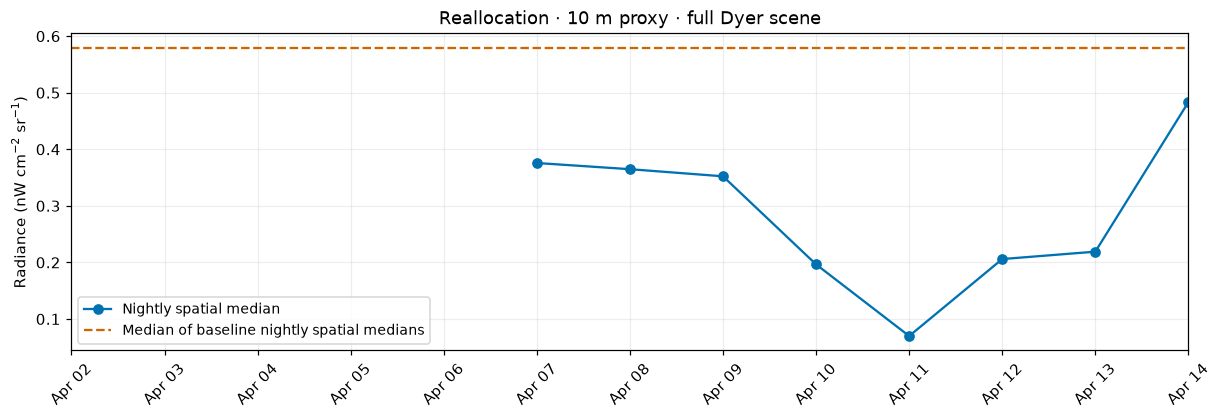

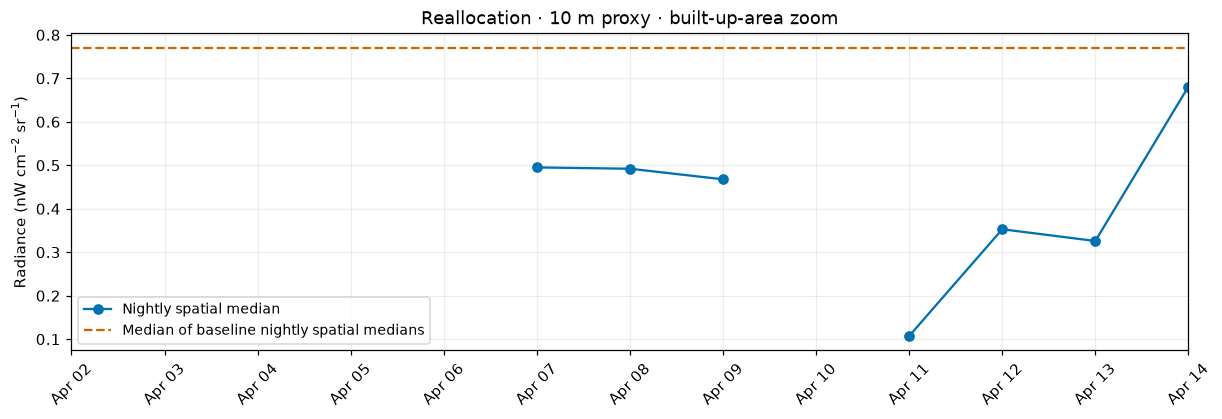

In [13]:
fig, table = radiance_figure(scene, SERIES_DATES)
publish(fig, f"{prefix}_04_full_scene_radiance")
save_table(table, f"{prefix}_full_scene_radiance")
fig, table = radiance_figure(scene, SERIES_DATES, ZOOM, "built-up-area zoom")
publish(fig, f"{prefix}_05_zoom_radiance")
save_table(table, f"{prefix}_zoom_radiance")

### Exploratory residual clusters (reallocation 10m, M0 method)

Clustering Reallocation · 10 m proxy / M0 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,5965562,4,46,True,4,7,4a,allocated10,M0


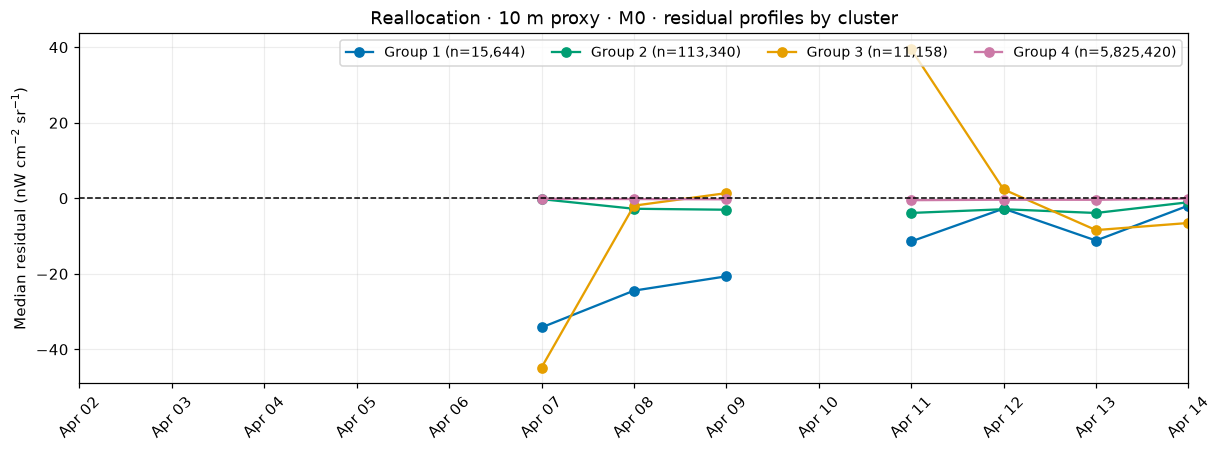

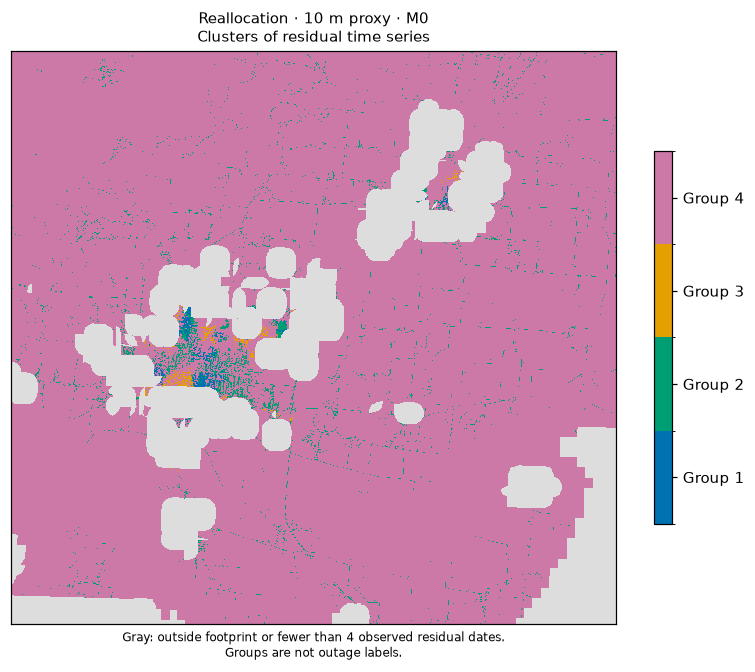

In [14]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table

## 4B. Reallocation at 10 m — M1

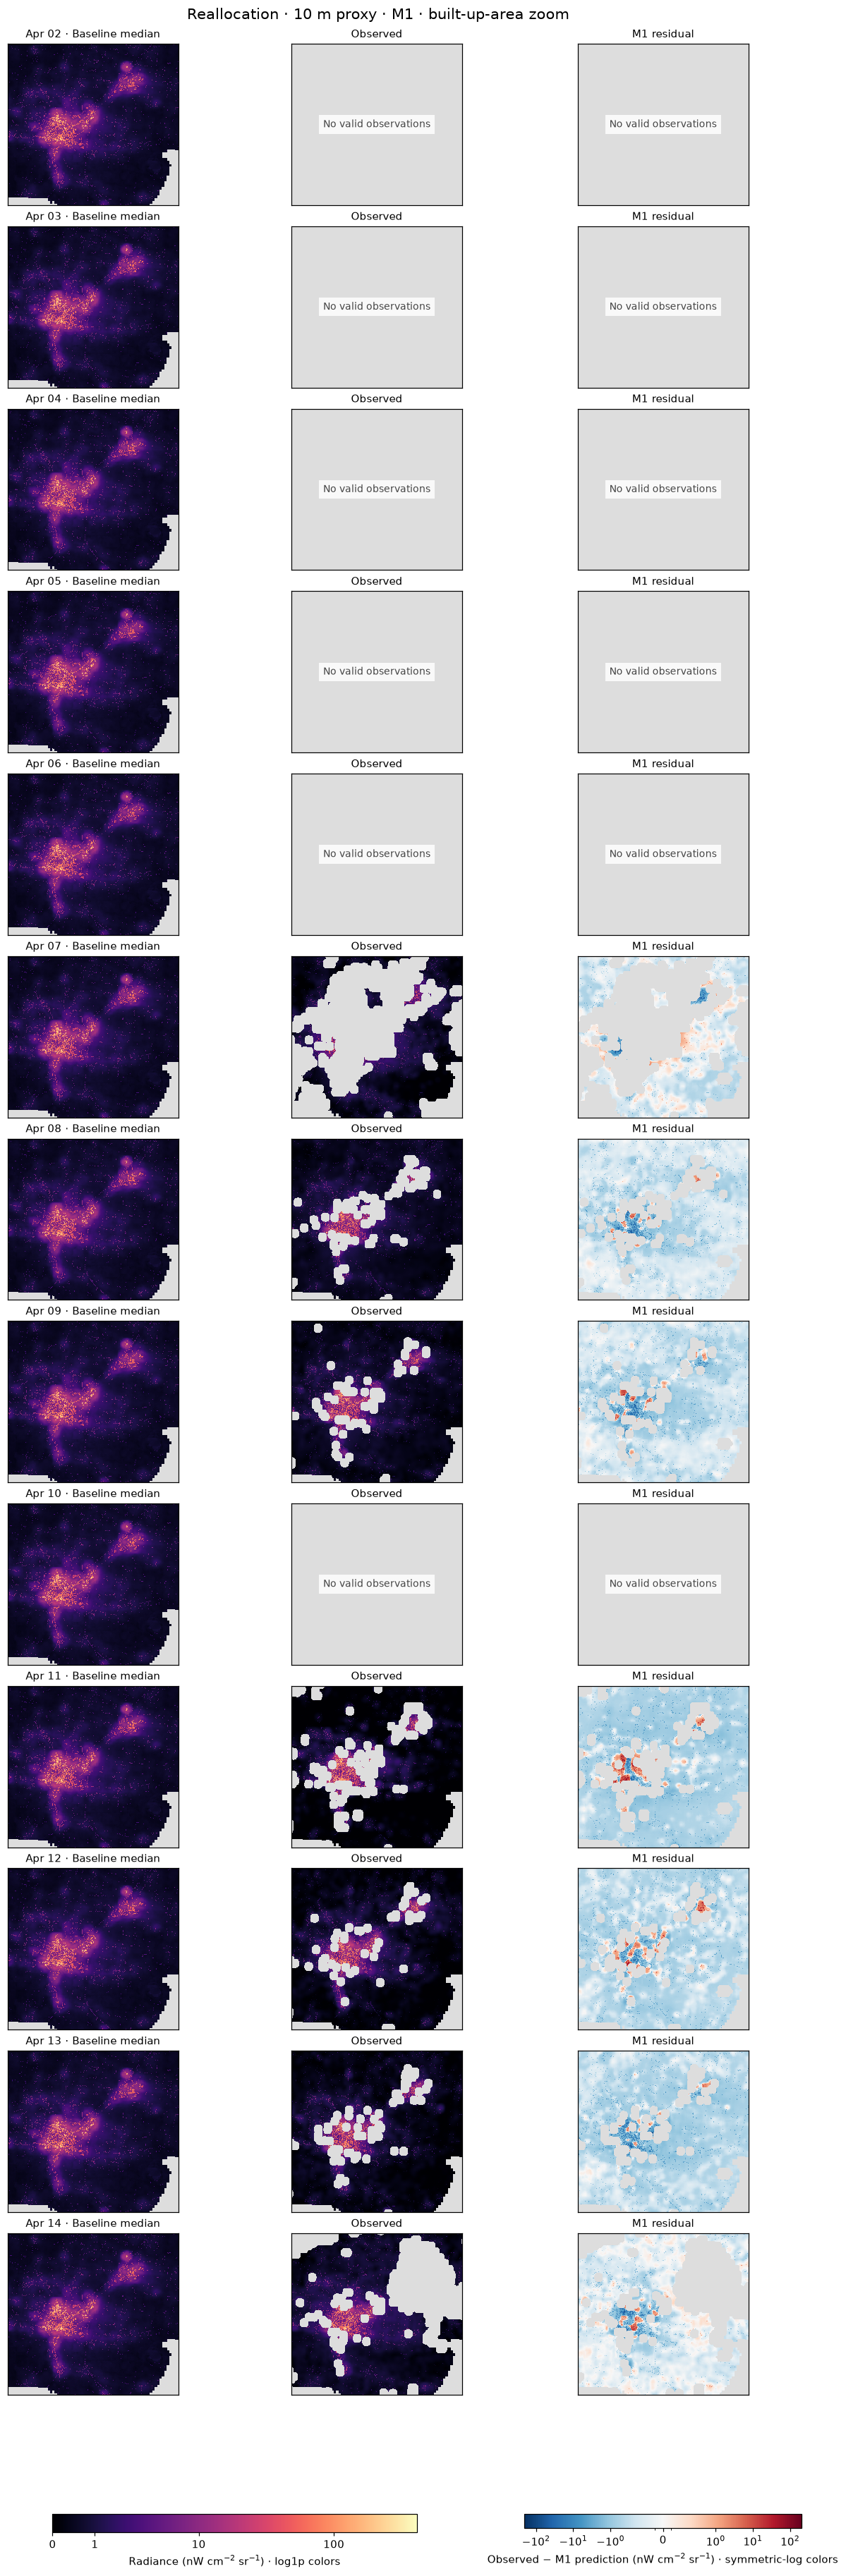

In [15]:
scene = scenes["allocated10"]
method = "M1"
prefix = "4b"
publish(comparison_panel(scene, method, ZOOM, IMAGE_DATES, RADIANCE_VMAX, RESIDUAL_LIMIT,
                         radiance_norm=RADIANCE_NORM, residual_norm=RESIDUAL_NORM),
        f"{prefix}_03_comparison")

### Spatial-median time series (reallocation at 10m, M1)

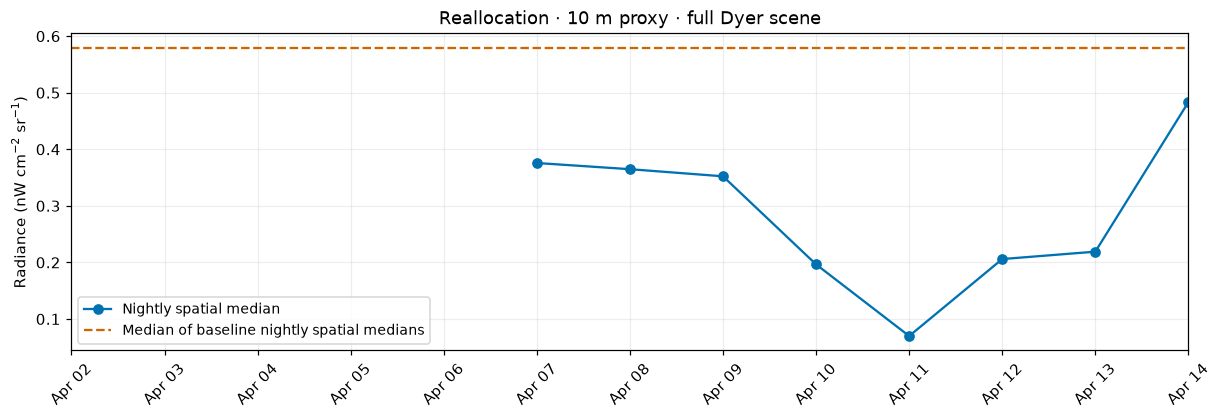

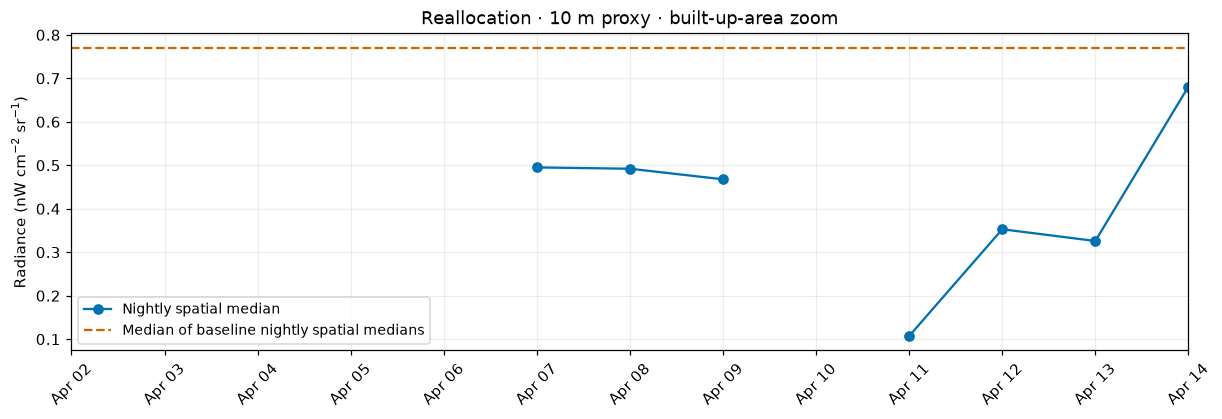

In [16]:
fig, table = radiance_figure(scene, SERIES_DATES)
publish(fig, f"{prefix}_04_full_scene_radiance")
save_table(table, f"{prefix}_full_scene_radiance")
fig, table = radiance_figure(scene, SERIES_DATES, ZOOM, "built-up-area zoom")
publish(fig, f"{prefix}_05_zoom_radiance")
save_table(table, f"{prefix}_zoom_radiance")

### Exploratory residual clusters (reallocation at 10m, M1 results)

Clustering Reallocation · 10 m proxy / M1 at full input resolution...


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,5965562,4,27,True,4,7,4b,allocated10,M1


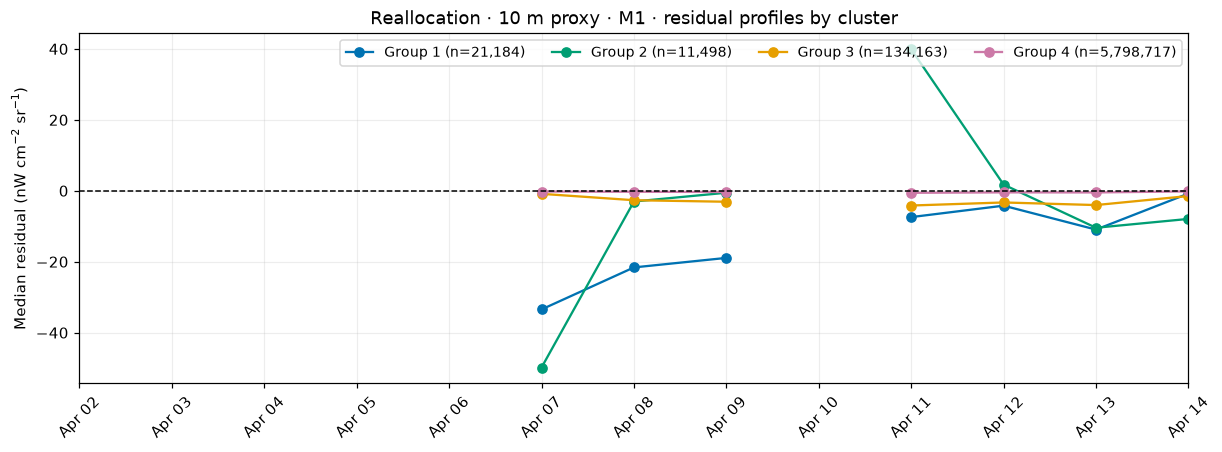

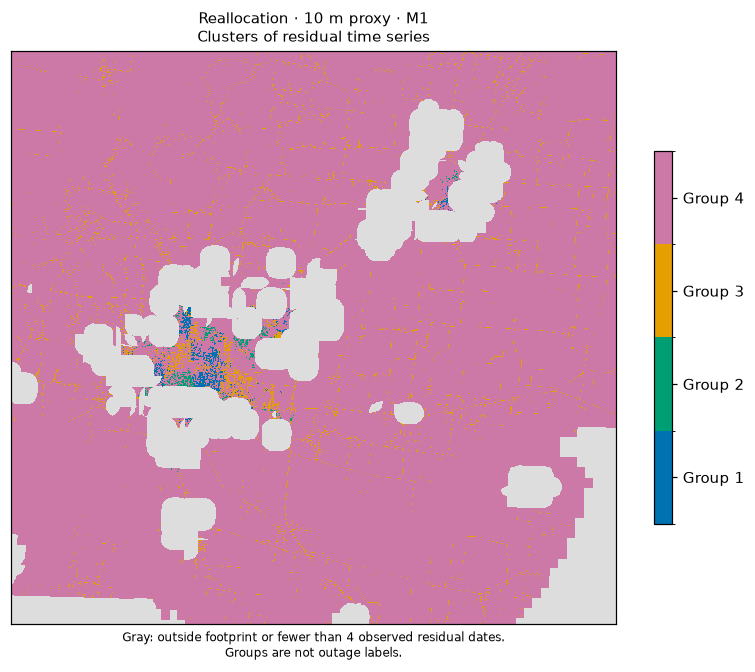

In [17]:
print(f"Clustering {scene.title} / {method} at full input resolution...")
cluster_image, cluster_table, cluster_info = cluster_scene(
    scene, method, ZOOM, CLUSTER_DATES, k=N_CLUSTERS, min_dates=MIN_CLUSTER_DATES,
    max_iter=CLUSTER_MAX_ITER, seed=CLUSTER_SEED,
)
cluster_info.update(section=prefix, dataset=scene.key, method=method)
cluster_summaries.append(cluster_info)
cluster_results[prefix] = cluster_info
save_table(cluster_table, f"{prefix}_cluster_profiles")
save_cluster_map(scene, cluster_image, f"{prefix}_clusters", cluster_info)
display(pd.DataFrame([cluster_info]).drop(columns=["used_date_columns"]))
profile_figure, map_figure = cluster_figures(
    scene, method, ZOOM, SERIES_DATES, cluster_image, cluster_table, cluster_info,
)
publish(profile_figure, f"{prefix}_07_cluster_profiles")
publish(map_figure, f"{prefix}_08_cluster_map")
del cluster_image, cluster_table

## 5. Dyersburg close-up: A2 versus 10 m reallocation residuals

April 8, 9, and 11; **A2 on the left, 10 m reallocation on the right**. The first
panel uses M0 and the second uses M1. The common map extent and residual color
limits make the visual comparison consistent. Each model retains its own observation
support; the fine structural pattern is not independent outage evidence.

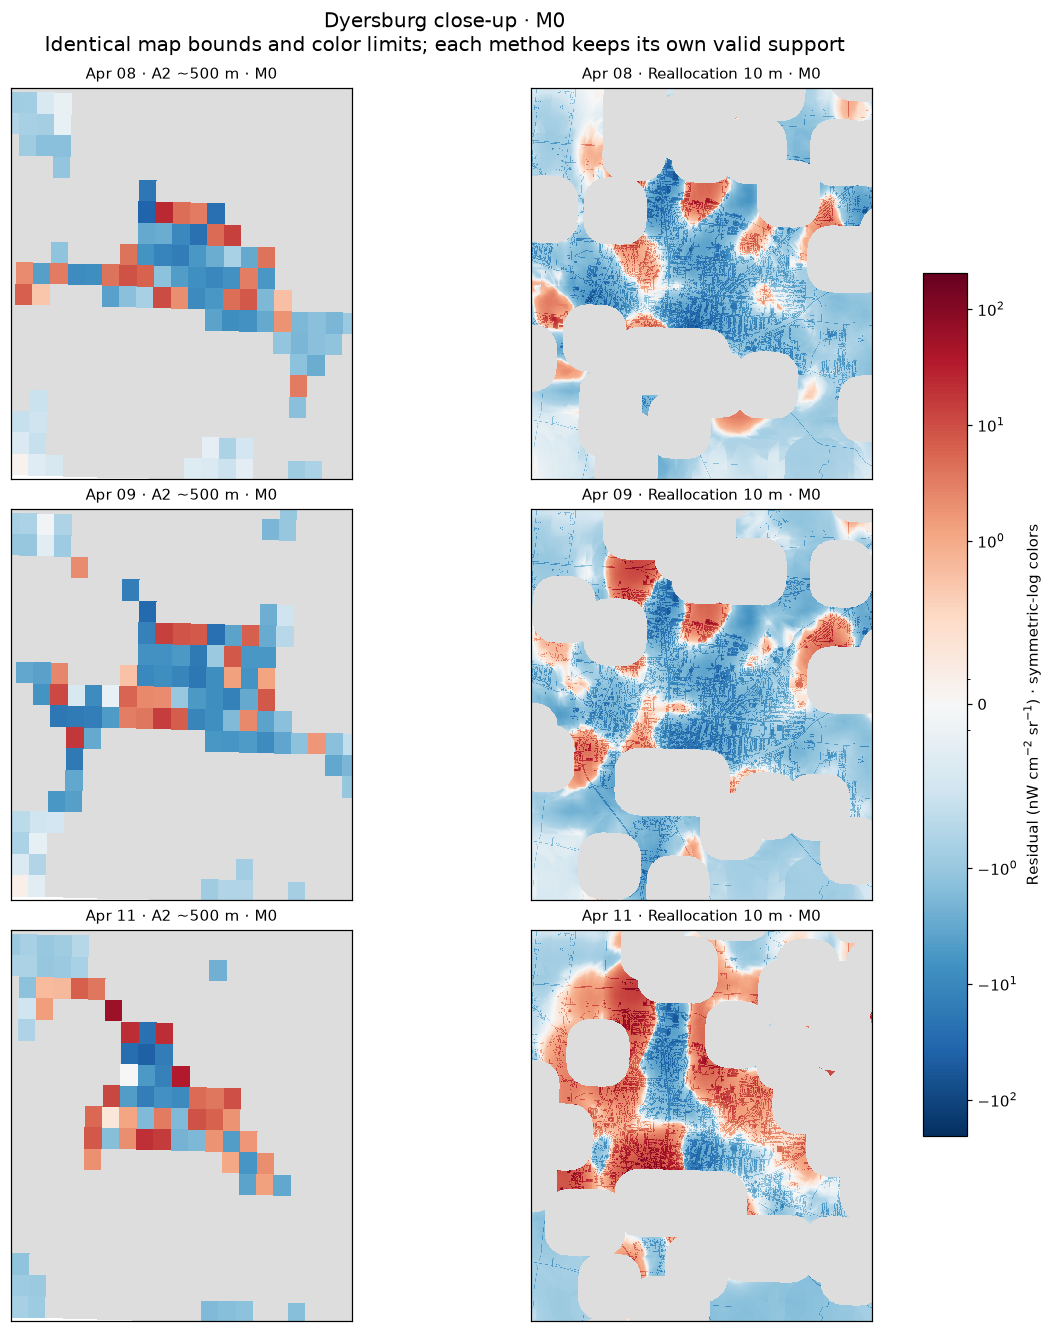

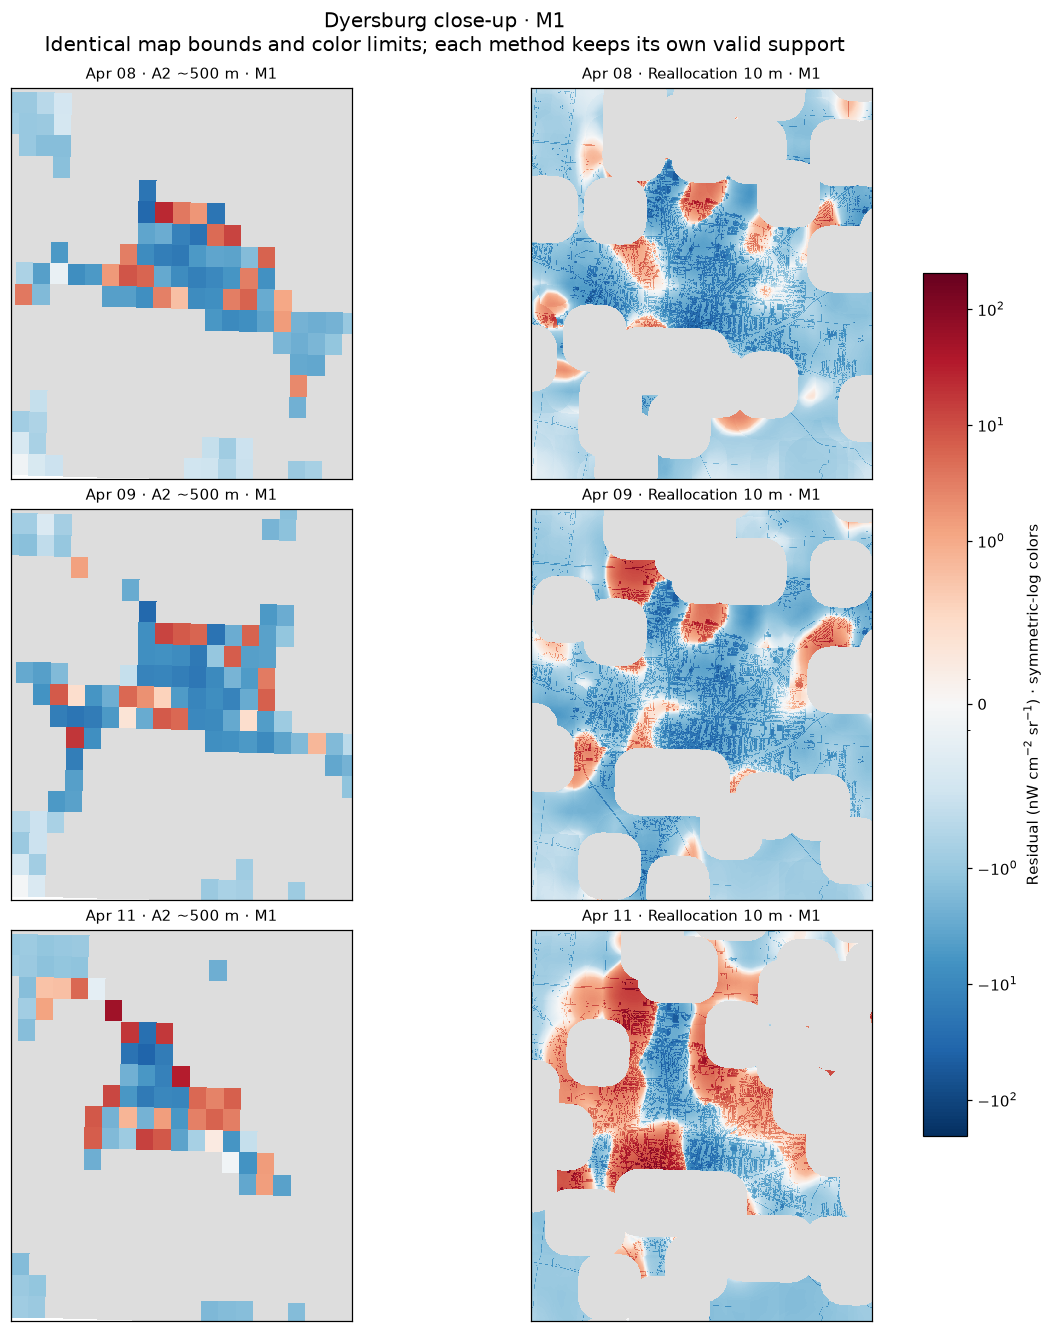

In [18]:
publish(close_comparison(scenes["a2"], scenes["allocated10"], "M0", CLOSE, CLOSE_DATES, RESIDUAL_LIMIT, norm=RESIDUAL_NORM),
        "05_close_dyersburg_M0")
publish(close_comparison(scenes["a2"], scenes["allocated10"], "M1", CLOSE, CLOSE_DATES, RESIDUAL_LIMIT, norm=RESIDUAL_NORM),
        "05_close_dyersburg_M1")

In [19]:
report_pdf.close()
summary = pd.DataFrame(cluster_summaries)
summary.to_csv(OUTPUT / "cluster_summary.csv", index=False)
parameters = {
    "zoom_wgs84": ZOOM_WGS84, "zoom_utm": ZOOM,
    "close_wgs84": CLOSE_WGS84, "close_utm": CLOSE,
    "image_dates": IMAGE_DATES.strftime("%Y-%m-%d").tolist(),
    "series_dates": SERIES_DATES.strftime("%Y-%m-%d").tolist(),
    "cluster_dates": CLUSTER_DATES.strftime("%Y-%m-%d").tolist(),
    "clusters": N_CLUSTERS, "min_cluster_dates": MIN_CLUSTER_DATES,
    "cluster_max_iter": CLUSTER_MAX_ITER, "seed": CLUSTER_SEED,
    "radiance_vmax": RADIANCE_VMAX, "residual_limit": RESIDUAL_LIMIT,
    "radiance_normalization": "log1p", "residual_normalization": "symlog",
    "residual_linthresh": RESIDUAL_LINTHRESH,
    "native_support": "intersection of published native comparison inputs",
    "fine_support": "own fine observations within the native analysis footprint",
}
manifest = {
    "status": "complete", "parameters": parameters, "input_sha256": input_hashes,
    "helper_sha256": file_hash(ROOT / "scripts/discussion_checkpoint.py"),
    "figures": len(figure_paths), "cluster_summaries": cluster_summaries,
    "output_sha256": {p.name: file_hash(p) for p in sorted(OUTPUT.iterdir())
                      if p.suffix in (".png", ".pdf", ".csv", ".tif")},
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Saved {len(figure_paths)} figures and PDF to {OUTPUT}")
display(summary.drop(columns=["used_date_columns"]))

Saved 25 figures and PDF to /home/daynan/research/ntl-outage-detection/data/published/discussion_checkpoint


,eligible_pixels,clusters,iterations,converged,minimum_observed_dates,seed,section,dataset,method
0,3105,4,23,True,4,7,2a,a2,M0
1,3105,4,30,True,4,7,2b,a2,M1
2,5965562,4,46,True,4,7,4a,allocated10,M0
3,5965562,4,27,True,4,7,4b,allocated10,M1
